# Landing Analysis

In [1]:
import os
import tomllib
import json
from datetime import date
from pathlib import Path
from importlib import  reload

# Add the parent directory to the system path
import sys
sys.path.append(os.path.abspath('..'))

from src.data_loaders import read_telemetry_csv, load_runway_db
from src.parsers import extract_date_name_tacview
from src.transformer_plotter import (transform_telemetry, 
                                    touchdown_discovery,
                                    style_result_table,
                                    plot_landing_profile,
                                    touchdown_plotter)

# Load the configuration file
notebook_dir = Path.cwd()
config_path = notebook_dir.parent / "config.toml"
PROJECT_ROOT = config_path.parent.parent
with config_path.open('rb') as f:
    config = tomllib.load(f)

REF_PATH             = PROJECT_ROOT / Path(config["db_path"]["REF_PATH"])
RESULTS_DIR         = PROJECT_ROOT / Path(config["output"]["RESULTS_DIR"])

# Set the CSV path
CSV_PATH            = PROJECT_ROOT / Path(config['input']['CSV_PATH'])
print(f"CSV_PATH: {CSV_PATH}")

CSV_PATH: C:\Users\Fardad\Desktop\Briefing\Caucausus\BE BRA - IFR Training\Tacview-20260802-201628-DCS-Host-BE ILS_260802.csv


In [2]:
# Make the output directory
record_date, mission_name = extract_date_name_tacview(CSV_PATH)
if record_date is None:
    record_date = date.today().strftime("%Y%m%d")

plots_output_path = RESULTS_DIR/f"[{record_date}] {mission_name}"
detailed_td_path = plots_output_path/"Detailed Touchdowns"

detailed_td_path.mkdir(parents=True, exist_ok=True)

print(f"record_date: {record_date}")

record_date: 20260802


## 1. Load DB once

In [3]:
# 1. Load DB
runway_db = load_runway_db(REF_PATH)

## 2. Touchdown Discovery

In [5]:
# 2. Touchdown Discovery

# Read the telemetry data
df = read_telemetry_csv(CSV_PATH)
# clean and transform the data
df_sub = transform_telemetry(df)
# Discover the touch downs
df_result = touchdown_discovery(df_sub, runway_db)

c:\Users\Fardad\Desktop\Landing Project\Approach-Landing-Analyzer\backend\src\data_loaders.py:27: DtypeWarning: Columns (0: Id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [6]:
df_result

,real_sortie_num,sortie_num,td_timestamp,td_timestamp_seconds,Name,Pilot,td_longitude,td_latitude,CAS_kt,AGL_ft,VS_fpm,vert_Acc_fpm2,vert_Jerk_fpm3,descent_quality,Airport,Runway,rwy_threshold_lat,rwy_threshold_long,touchdown_to_threshold_ft
0,1,1,2016-06-21 05:06:29.096196,3911.496270,F-16C_50,< 404C > Ghost,42.476883,42.177128,165,4.764905,-497,1652.856960,8.863589e+06,"[-800 , -350]",UGKO,07,42.174801,42.467701,2623
1,1,1,2016-06-21 05:07:41.696127,3984.096201,F-16C_50,< 404C > Dragon 5,42.468694,42.175957,163,7.342742,-459,14307.860999,7.911567e+05,"[-800 , -350]",UGKO,07,42.174801,42.467701,499
2,1,1,2016-06-21 05:09:37.696016,4100.096090,F-16C_50,< 404 > Hawk_7,42.471560,42.176396,166,7.723623,-255,371.706963,6.480542e+05,"[-300 , -150]",UGKO,07,42.174801,42.467701,1194
3,1,1,2016-06-21 05:11:51.795888,4234.195962,F-16C_50,< 404C > Eclipse,42.473634,42.176713,150,7.955309,-378,1978.832703,3.879945e+05,"[-800 , -350]",UGKO,07,42.174801,42.467701,1749
4,1,1,2016-06-21 05:29:28.794880,5291.194954,F-16C_50,< 404C > IR.shadow,42.471749,42.176412,156,6.406063,-492,4310.449104,2.219293e+06,"[-800 , -350]",UGKO,07,42.174801,42.467701,1242
5,1,1,2016-06-21 05:31:25.894768,5408.294842,F-16C_50,< 404 > A D L E R,42.473736,42.176665,150,7.938788,-217,2930.402527,3.491977e+05,"[-300 , -150]",UGKO,07,42.174801,42.467701,1767
6,1,1,2016-06-21 05:36:40.194469,5722.594543,F-16C_50,< 404C > Phoenix,42.471372,42.176251,144,4.740250,-753,9293.575172,8.227670e+06,"[-800 , -350]",UGKO,07,42.174801,42.467701,1124
7,1,1,2016-06-21 05:36:46.794462,5729.194536,F-16C_50,< 404C > Rough14,42.465807,42.175573,161,3.282004,-284,-9676.095428,3.875248e+05,"[-300 , -150]",UGKO,07,42.174801,42.467701,584
8,1,1,2016-06-21 05:39:35.794301,5898.194375,F-16C_50,<404>MOS,42.471500,42.176352,154,7.528070,-36,3020.288029,1.664571e+05,"[-150 , 0]",UGKO,07,42.174801,42.467701,1172
9,2,2,2016-06-21 05:41:56.194167,6038.594241,F-16C_50,< 404 > A D L E R,42.473126,42.176627,139,7.431351,-269,1471.058464,7.740291e+05,"[-300 , -150]",UGKO,07,42.174801,42.467701,1610


## 3. CSS Stylized Results Table

In [7]:
# 3. CSS Stylized Results Table
stylized_table = style_result_table(df_result, plots_output_path, record_date)
stylized_table

Exported styled HTML.
Exported table image.


Sortie,Touchdown Time,Aircraft,Pilot,CAS (kt),VS (fpm),Airport,Runway,Touchdown to Threshold (ft)
1,2016-06-21 05:06:29.096196,F-16C_50,< 404C > Ghost,165,-497,UGKO,07,2623
1,2016-06-21 05:07:41.696127,F-16C_50,< 404C > Dragon 5,163,-459,UGKO,07,499
1,2016-06-21 05:09:37.696016,F-16C_50,< 404 > Hawk_7,166,-255,UGKO,07,1194
1,2016-06-21 05:11:51.795888,F-16C_50,< 404C > Eclipse,150,-378,UGKO,07,1749
1,2016-06-21 05:29:28.794880,F-16C_50,< 404C > IR.shadow,156,-492,UGKO,07,1242
1,2016-06-21 05:31:25.894768,F-16C_50,< 404 > A D L E R,150,-217,UGKO,07,1767
1,2016-06-21 05:36:40.194469,F-16C_50,< 404C > Phoenix,144,-753,UGKO,07,1124
1,2016-06-21 05:36:46.794462,F-16C_50,< 404C > Rough14,161,-284,UGKO,07,584
1,2016-06-21 05:39:35.794301,F-16C_50,<404>MOS,154,-36,UGKO,07,1172
2,2016-06-21 05:41:56.194167,F-16C_50,< 404 > A D L E R,139,-269,UGKO,07,1610


## 4. Plot Approach Profiles

All Landing Profiles Plotted!


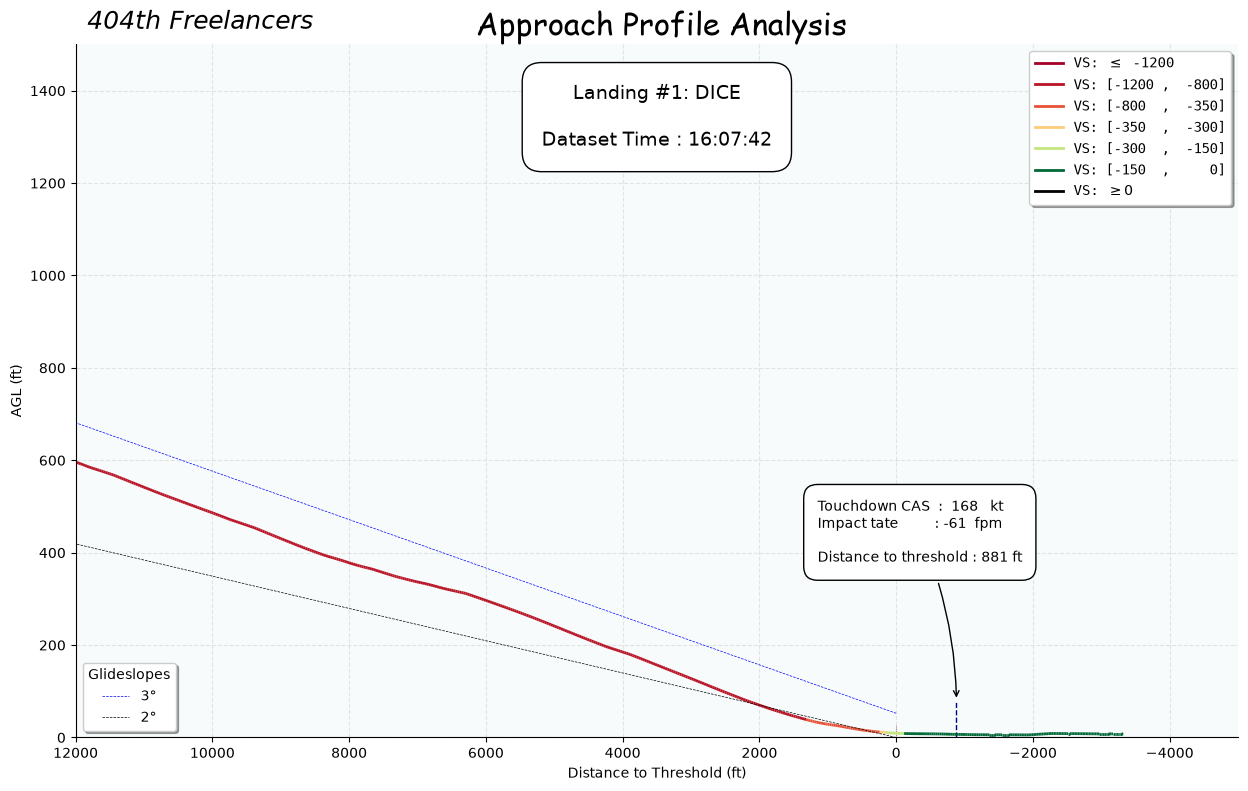

In [8]:
# 3. Plot/Export Profiles

for pilot in df_result['Pilot'].sort_values().unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        is_sortie = plot_landing_profile(df_sub, df_result, pilot, sortie_num, 
                                        plots_output_path, record_date, 
                                        close_fig = False)
print("All Landing Profiles Plotted!")


## 5. Detailed Touchdowns (optional)

All Touchdowns Plotted!


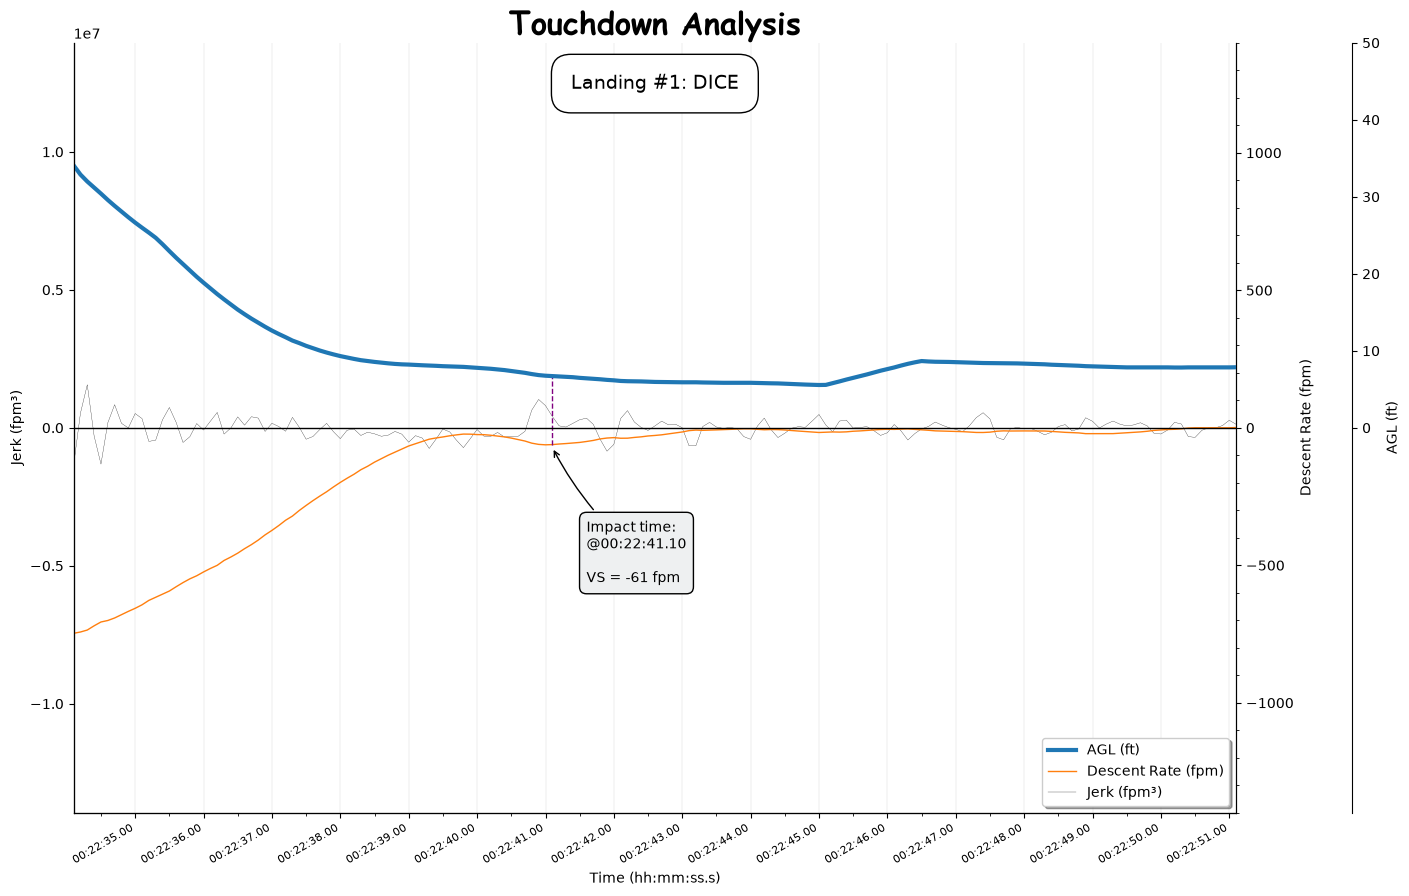

In [9]:
# Plot/Export Touchdowns
for pilot in df_result['Pilot'].unique():
    for sortie_num in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        touchdown_plotter(df_sub, df_result, pilot, sortie_num, 
                        detailed_td_path, record_date, 
                        close_fig = False)
print("All Touchdowns Plotted!")